# Power Transformation

In [21]:
import pandas
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy

pandas.set_option('display.max_columns', None)
pandas.set_option('display.max_rows', None)

In [22]:
df = pandas.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv" , usecols=['Age', 'Fare' , 'Survived'])

# Remove the null value from the data
siAge = SimpleImputer(strategy='mean')
sIFare = SimpleImputer(strategy='mean')

df['Age'] = siAge.fit_transform(df[['Age']])

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


#### Distribution before transforming the graph

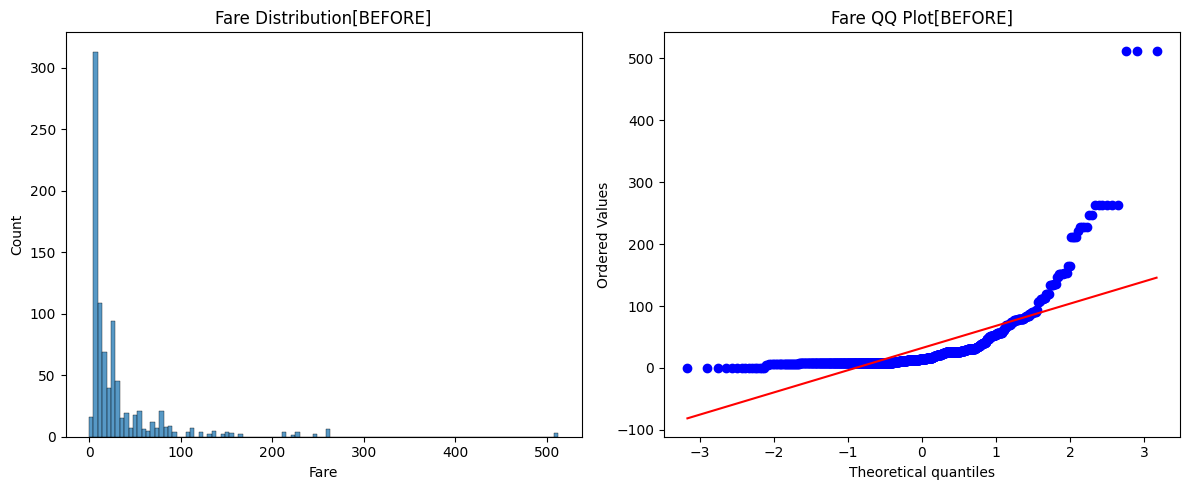

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Fare"], ax=axes[0])
axes[0].set_title("Fare Distribution[BEFORE]")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Fare'], dist="norm", plot=plt)
axes[1].set_title("Fare QQ Plot[BEFORE]")

# Adjust spacing and display
plt.tight_layout()
plt.show()

#### Lets Transform
PowerTransformer applies the power transformation and, by default, standardizes the transformed data.


### 1.> Box-Cox [it only consider +ve value]

In [24]:
def calcFormulae(x):
  return x +1

funcTrans = FunctionTransformer(calcFormulae)
df['Fare'] = funcTrans.fit_transform(df[['Fare']])

powTrans = PowerTransformer(method='box-cox')
df['Fare'] = powTrans.fit_transform(df[['Fare']])

### 2.> Yeo-Johnson Algorithm

In [25]:
powTrans = PowerTransformer(method='yeo-johnson')
df['Fare'] = powTrans.fit_transform(df[['Fare']])

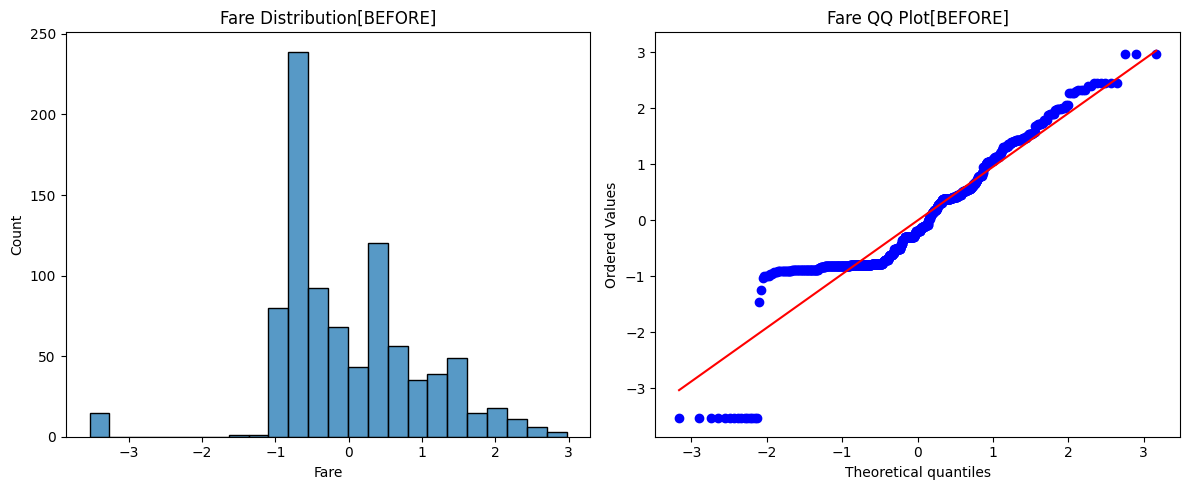

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Fare"], ax=axes[0])
axes[0].set_title("Fare Distribution[BEFORE]")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Fare'], dist="norm", plot=plt)
axes[1].set_title("Fare QQ Plot[BEFORE]")

# Adjust spacing and display
plt.tight_layout()
plt.show()